## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

In [3]:
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
import multiprocess
from auditoryforage.AF_env import AF2p, AuditoryForaging,AuditoryForagingReward2


## train

food reard list:  ['10', '1258', '2505', '3752', '5000']
5678vs9_15


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Box(-inf, inf, (19,), float32)
epoch 0
using 2235 of trails
using 2226 of trails
using 2244 of trails


/Users/yc/repo/auditory-foraging-IRC/ult.py:560: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


using 2163 of trails
using 2243 of trails


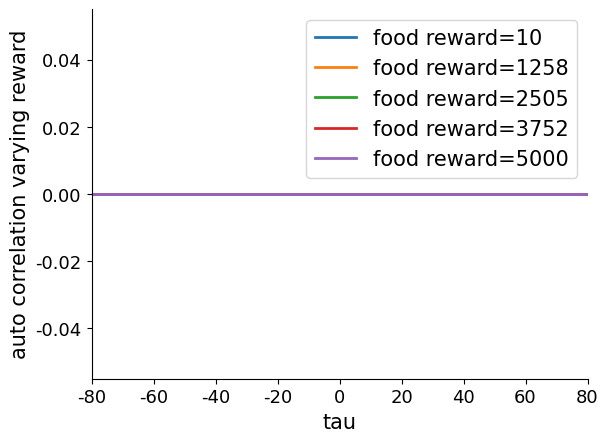

epoch 1


KeyboardInterrupt: 

In [4]:
modelname = 'varynodes'
# training hyper params
epoch_size = 555
no_episodes=11111
n_epoch = 55
n_seed = 1
modeli = 0
attcost=-1.6
facost=-50

# reward list
vmin, vmax = 10, 5000
food_reward_list = np.linspace(vmin, vmax, 5)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])
env_param = [0, None, attcost, .25, facost, 0, 0]
seed=0
n_nodes=[15,40]


for n_node in n_nodes:
    thismodel = f'{modelname}_{n_node}'
    print(thismodel)
    np.random.seed(seed)
    task = AuditoryForagingReward2(spec={'agent': 
                                         {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]},
                                'experiment':{                              'no_signal_nodes':n_node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                clip_range=0.01, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",batch_size=512)
    print(taskbelief.observation_space)

    for epochi in range(0, 44):
        
        print('epoch', epochi)
        model.learn(total_timesteps=epoch_size,
                    tb_log_name=thismodel,
                    reset_num_timesteps=False,
                    )
        model.save(f'ycstore/{thismodel}_{epochi}')

        # eval
        eps=0.001
        # collect trial data
        
        def eval_wrapper(a):
            episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                    num_steps=100000, deterministic=True)
            return episode

        with multiprocess.Pool(processes=6) as pool:
            all_episode_data = pool.map(eval_wrapper, range(no_episodes))

        plotname='plotname'
        all_reward_res=[]# k: v = foodreward: this food reward res

        for episode in all_episode_data:
            r=episode['trial_food_reward_idx']
            p1p2=episode['p1p2']
            att_time_list,lick_time_list=[],[]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))

            all_reward_res.append((r,p1p2[0], p1p2[1],att_time_list, lick_time_list,episode))
        import pandas as pd
        df = pd.DataFrame(all_reward_res,columns = ['reward', 'p1', 'p2', 'att_time', 'lick_time', 'episode'])

        # eval
        all_reward_res={} # k: v = foodreward idx: this food reward res
        for r in range(len(food_reward_list)):
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
            all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len

        for episode in all_episode_data:
            attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
            att_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
            if episode['actions'][-1][0] == 1:
                lick_time_list.append(len(episode['states']))
            else:
                lick_time_list.append(None)
            trial_len.append(len(episode['actions']))

        # auto correlation varying reward
        for food_reward_idx in range(len(food_reward_list)):
            att_seq_list = []
            for episode in all_episode_data:
                if episode['trial_food_reward_idx']==food_reward_idx:
                    att_seq_list.append([float(elt[1]) for elt in episode['actions']])
            # Sorting based on increasing trial length
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            print(f'using {len(sorted_list_of_lists)} of trails')
            sequences = sorted_list_of_lists[-len(sorted_list_of_lists)//2:] # Choosing what range of trial lengths to use. Could modify to be more consistent.
            normalized_sequences = []
            max_length = 0
            for sequence in sequences:
                normalized_seq = np.array(sequence)
                if not np.isnan(normalized_seq.any()):
                    normalized_sequences.append(normalized_seq)
                    max_length = max(max_length, len(normalized_seq))    
                
            padded_sequences = []
            for seq in normalized_sequences:
                padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                padded_sequences.append(padded_seq)

            autocorrelation_sum = np.zeros(2 * max_length - 1)
            for seq in padded_sequences:
                autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

            average_autocorrelation = autocorrelation_sum / len(padded_sequences)
            xs=np.arange(0,len(average_autocorrelation),1)
            xs=xs-len(xs)//2
            plt.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        plt.legend()
        plt.xlabel('tau')
        plt.xlim(-80,80)
        plt.ylabel('auto correlation varying reward')
        plt.show()
